In [5]:
from sklearn.model_selection import train_test_split

from src.plotting import plt_sample
from src.configs import TrainingConfig
from src.dataset import get_data_loaders, load_preprocessed_dataset
import os
import shutil
import zipfile
from pathlib import Path

import torch
import requests
import torchvision
import numpy as np
import pandas as pd
from torch import Tensor
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
train_cfg = TrainingConfig()
x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=train_cfg.test_size,
    random_state=train_cfg.random_state,
)

In [6]:
def get_data_loaders(
        x_train: Tensor,
        y_train: Tensor,
        x_valid: Tensor,
        y_valid: Tensor,
        batch_size: int,
        transform,
    ):
    train_ds = SegmentationDataset(
        images=x_train,
        masks=y_train,
        transform=transform,
    )

    valid_ds = SegmentationDataset(
        images=x_valid,
        masks=y_valid,
        transform=None,   # no augmentation for validation
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_batch_size = int(np.clip(batch_size * 2, 1, 64))
    valid_loader = DataLoader(valid_ds, batch_size=valid_batch_size, shuffle=False)

    return train_loader, valid_loader

class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, images: Tensor, masks: Tensor, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].cpu().numpy()  # Albumentations expects numpy HWC
        mask = self.masks[idx].cpu().numpy()

        # If tensor is CHW convert to HWC
        if img.ndim == 3:
            img = img.transpose(1, 2, 0)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        # back to torch
        img = torch.tensor(img).permute(2, 0, 1).float()
        mask = torch.tensor(mask).long()
        return img, mask

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

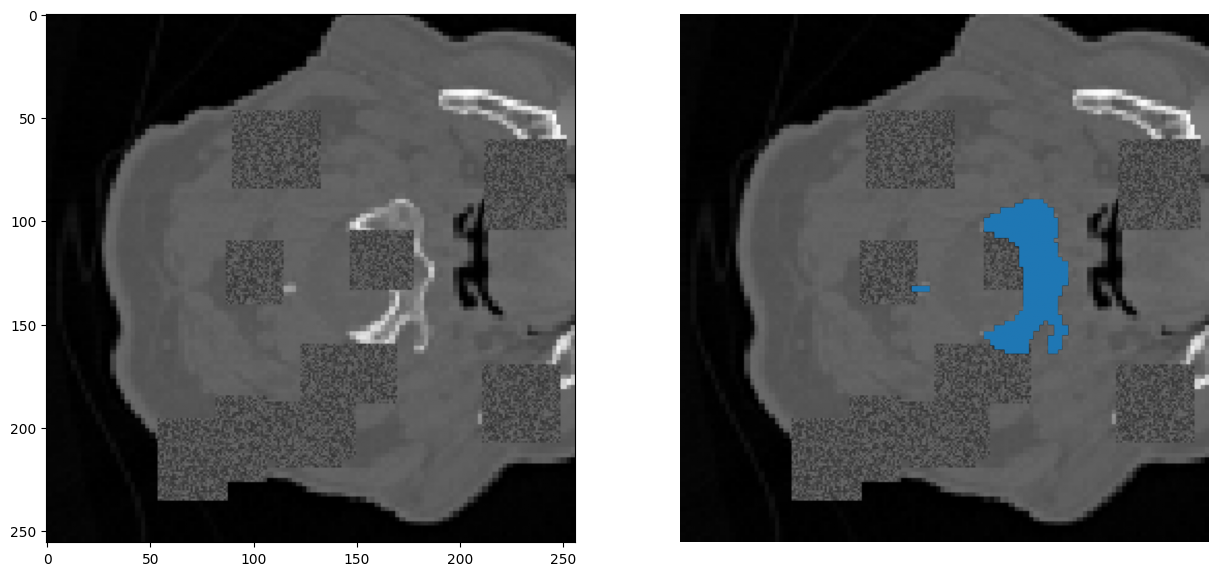

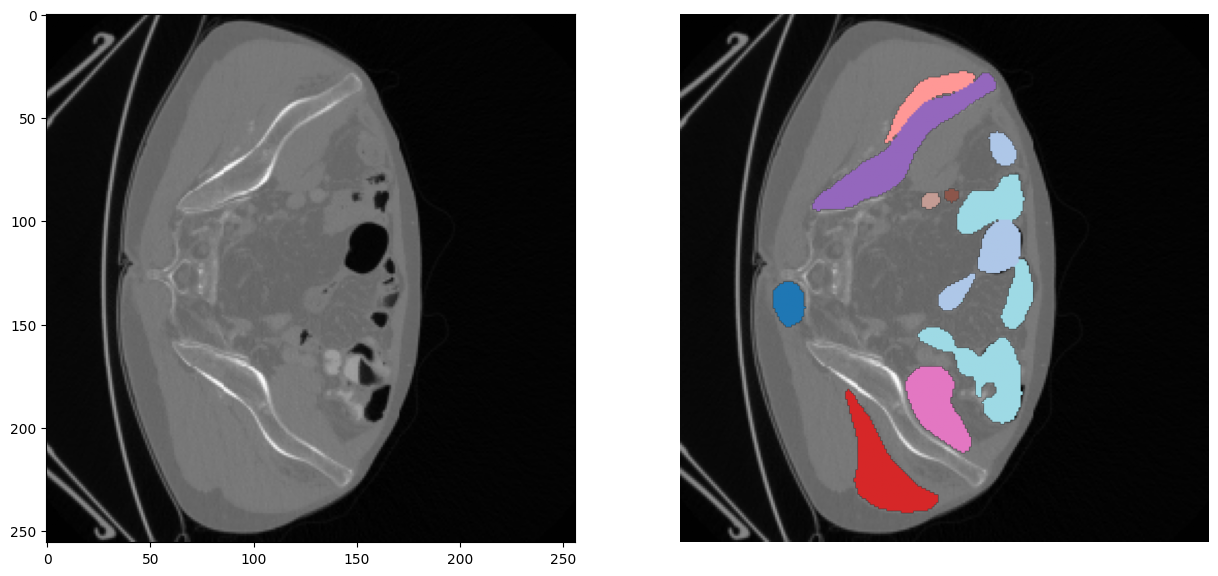

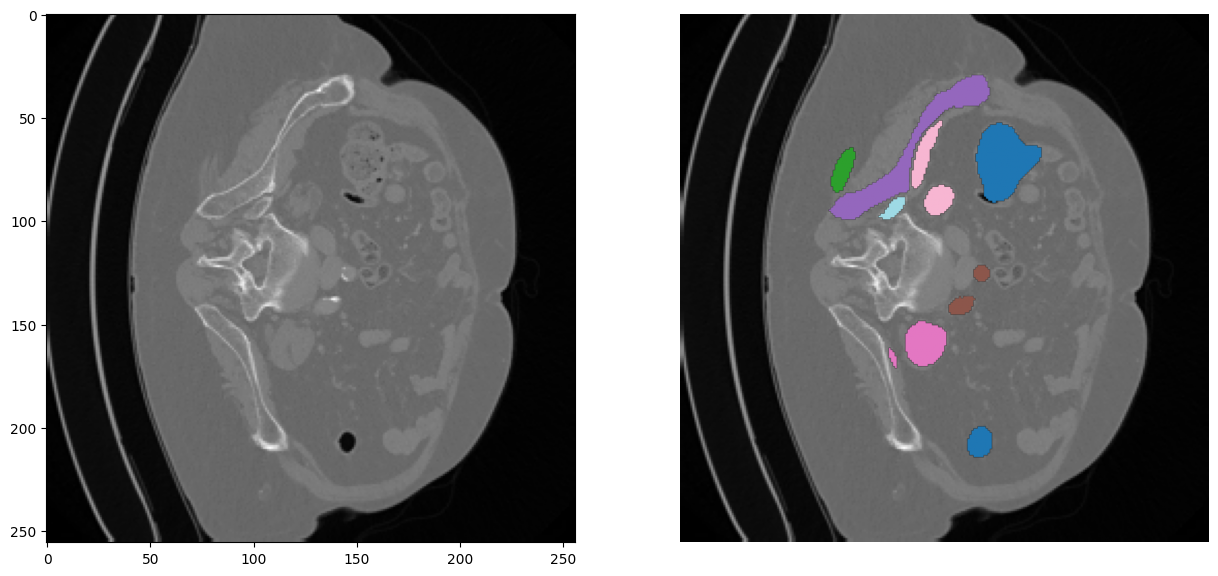

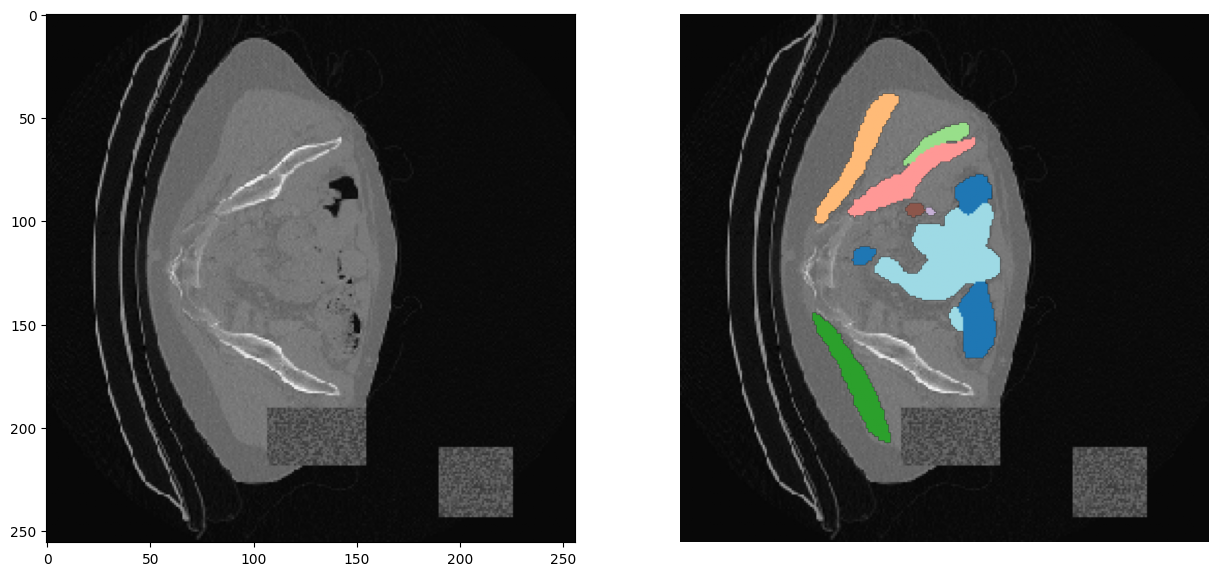

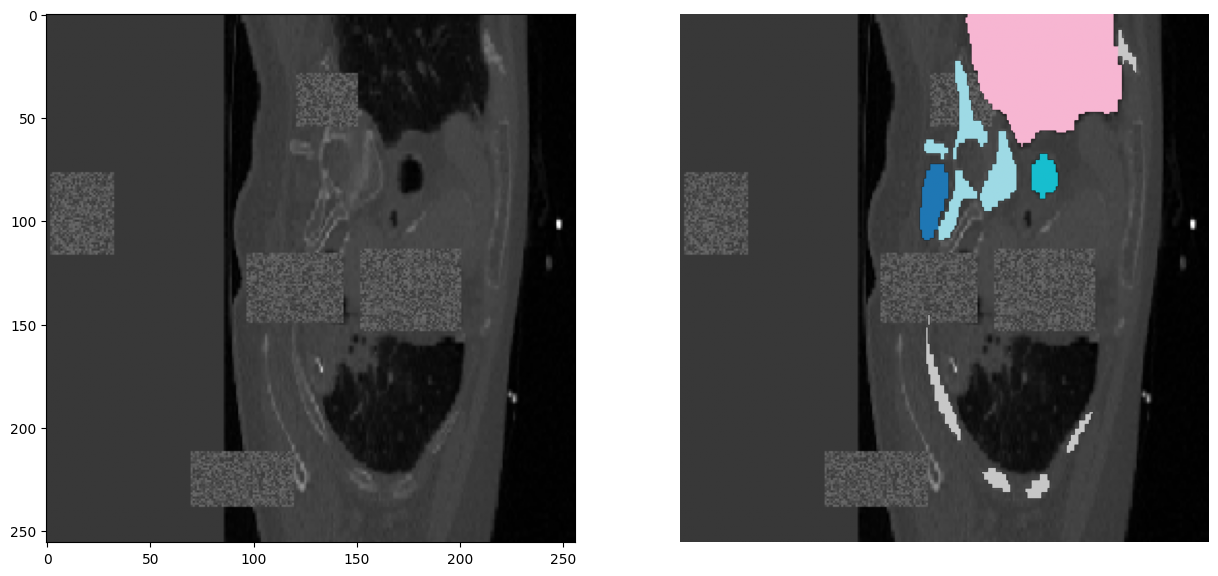

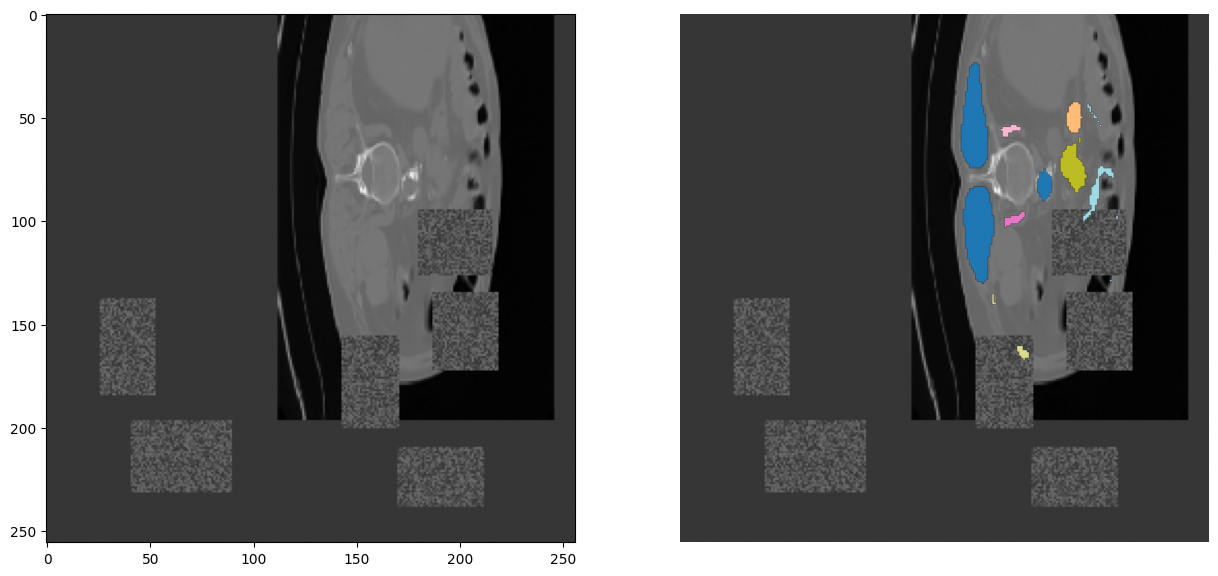

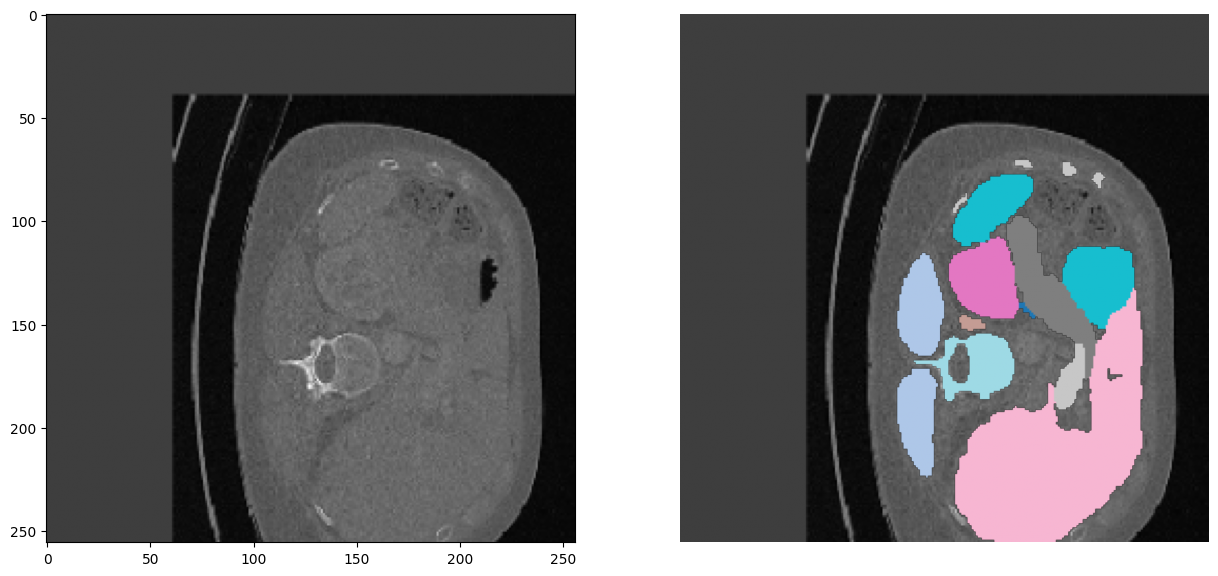

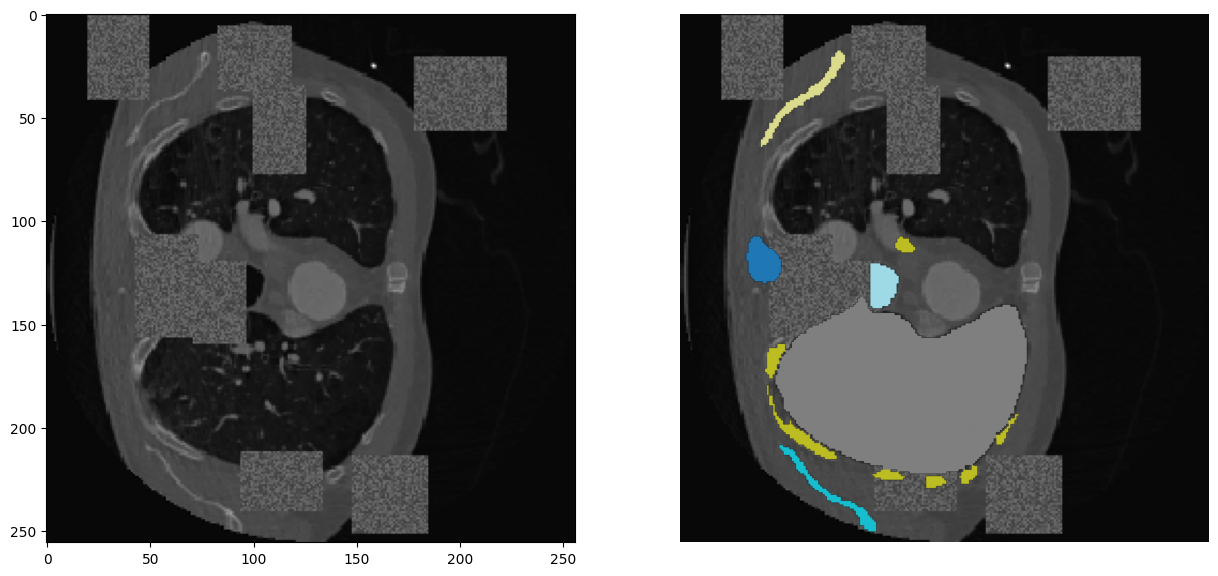

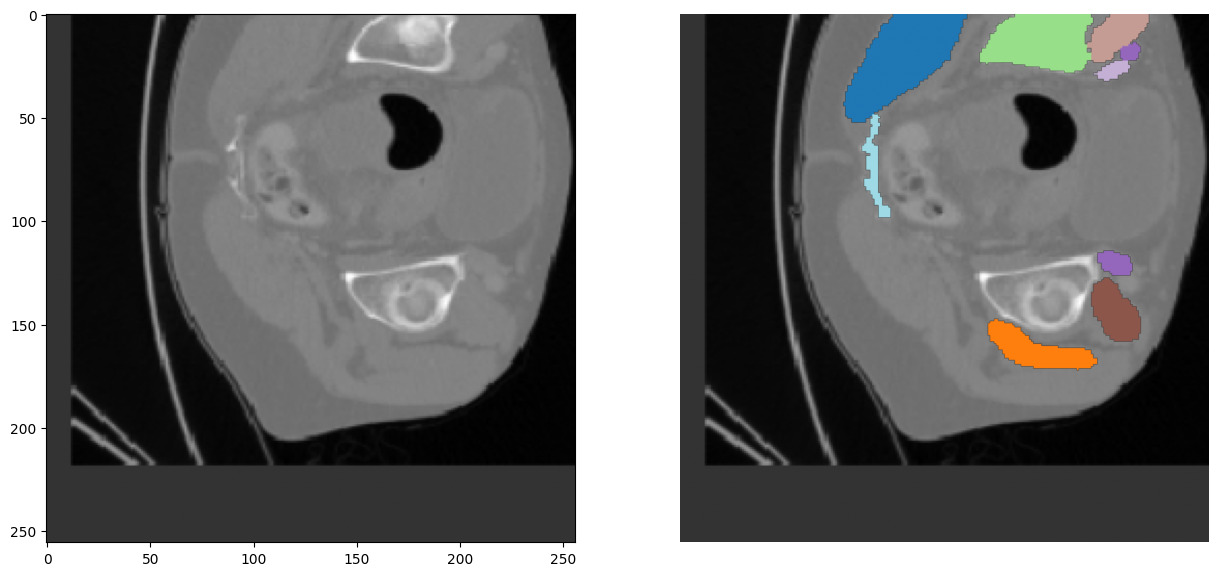

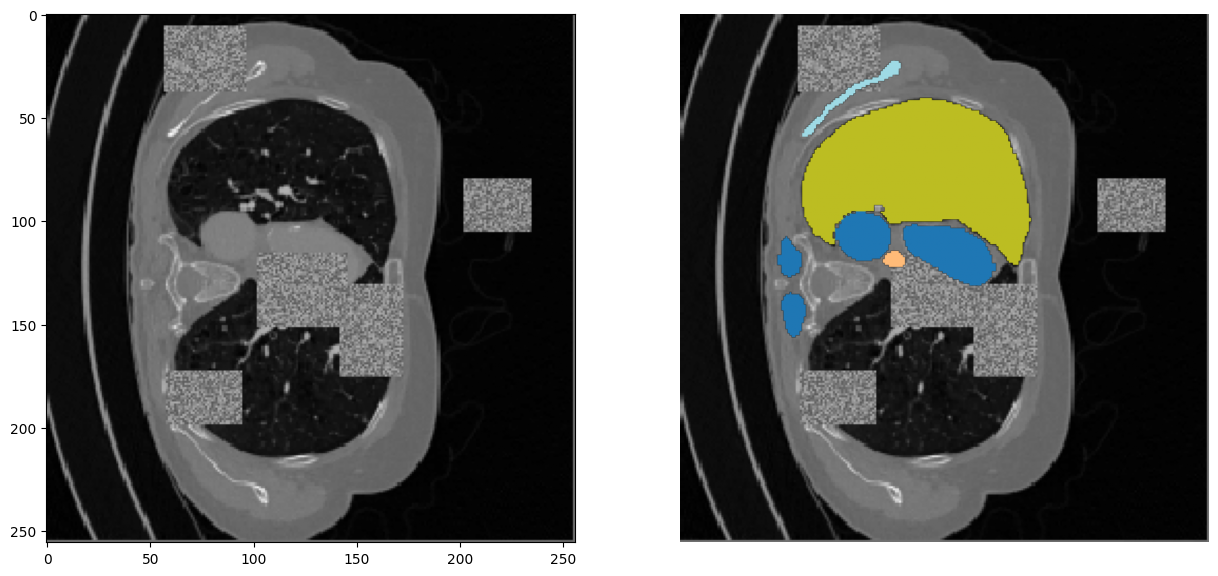

In [21]:
train_transform = A.Compose(
    [
        A.Affine((0.5, 2), 0.2, fill=0),
        A.VerticalFlip(),
        A.CoarseDropout(num_holes_range=[1, 10], fill="random"),
        A.ElasticTransform(),
        # A.GaussianBlur(),
    ],
    additional_targets={"mask": "mask"},
)

train_loader, valid_loader = get_data_loaders(
    x_train,
    y_train,
    x_valid,
    y_valid,
    batch_size=10,
    transform=train_transform
)
batch_x, batch_y = next(iter(train_loader))
for x, y in zip(batch_x, batch_y):
    plt_sample(x[0], y)